# Target Detection Experiment

Eine Ingenieurin untersucht Möglichkeiten zur Verbesserung der Zielerkennung auf einem Radarschirm.

## Faktor A: Ground Clutter

Hintergrundrauschen auf dem Bildschirm

- Low
- Medium
- High

## Faktor B: Filter Type

Filtertyp

- Type 1
- Type 2

## Antwortvariable

Signalintensität bei der Zielerkennung

Je kleiner die benötigte Intensität, desto besser die Zielerkennung.

## Blockfaktor

Operator

Vier zufällig ausgewählte Bedienpersonen.

Jede Bedienperson führt alle sechs Faktorkombinationen durch.

## Versuchsplan

- 3 × 2 faktorieller Versuchsplan
- 4 Blöcke
- 24 Versuche insgesamt

## Datengrundlage

![title](../img/table5-21.png)

## Ziele der Analyse

- Faktoriellen Versuchsplan mit Blockung erstellen
- Faktorielle ANOVA mit Blockung
- Fixed Effects für Ground Clutter und Filter Type
- Random Effect für Operator
- Schätzung von Varianzkomponenten

# Versuchsplan erzeugen

Der Versuch besteht aus

- Faktor A: Ground Clutter (3 Stufen)
- Faktor B: Filter Type (2 Stufen)
- 4 Blöcken (Operatoren)

Jeder Operator führt alle sechs Behandlungskombinationen durch.

Damit ergibt sich ein faktorieller Versuchsplan in einem randomisierten vollständigen Block.

In [1]:
from pyDOE3 import fullfact
import pandas as pd

design = fullfact([
    3,  # Ground Clutter
    2   # Filter
])

design = pd.DataFrame(
    design,
    columns=[
        "GroundClutter",
        "Filter"
    ]
)

design

,GroundClutter,Filter
0,0.0,0.0
1,1.0,0.0
2,2.0,0.0
3,0.0,1.0
4,1.0,1.0
5,2.0,1.0


In [2]:
design["GroundClutter"] = (
    design["GroundClutter"]
    .map({
        0:"Low",
        1:"Medium",
        2:"High"
    })
)

design["Filter"] = (
    design["Filter"]
    .map({
        0:"Type 1",
        1:"Type 2"
    })
)

design

,GroundClutter,Filter
0,Low,Type 1
1,Medium,Type 1
2,High,Type 1
3,Low,Type 2
4,Medium,Type 2
5,High,Type 2


In [3]:
design = pd.concat(
    [
        design.assign(Operator=i)
        for i in range(1,5)
    ],
    ignore_index=True
)

design.head()

,GroundClutter,Filter,Operator
0,Low,Type 1,1
1,Medium,Type 1,1
2,High,Type 1,1
3,Low,Type 2,1
4,Medium,Type 2,1


In [4]:
design = (
    design.groupby("Operator")
          .sample(
              frac=1,
              random_state=42
          )
          .reset_index(drop=True)
)

design

,GroundClutter,Filter,Operator
0,Low,Type 1,1
1,Medium,Type 1,1
2,High,Type 2,1
3,High,Type 1,1
4,Medium,Type 2,1
5,Low,Type 2,1
6,Low,Type 2,2
7,Low,Type 1,2
8,Medium,Type 1,2
9,High,Type 1,2


# Datensatz anlegen

In [5]:
import pandas as pd

df = pd.DataFrame({

    "Operator":[
        1,1,1,1,1,1,
        2,2,2,2,2,2,
        3,3,3,3,3,3,
        4,4,4,4,4,4
    ],

    "Filter":[
        1,2,1,2,1,2,
        1,2,1,2,1,2,
        1,2,1,2,1,2,
        1,2,1,2,1,2
    ],

    "GroundClutter":[
        "Low","Low",
        "Medium","Medium",
        "High","High"
    ] * 4,

    "Intensity":[
        90,86,102,87,114,93,
        96,84,106,90,112,91,
        100,92,105,97,108,95,
        92,81,96,80,98,83
    ]
})

df.head()

,Operator,Filter,GroundClutter,Intensity
0,1,1,Low,90
1,1,2,Low,86
2,1,1,Medium,102
3,1,2,Medium,87
4,1,1,High,114


# Faktorieller Versuchsplan mit Blockung

Jeder Operator bildet einen Block.

Innerhalb jedes Blocks werden alle sechs Behandlungskombinationen untersucht.

In [6]:
means = df.pivot_table(
    values="Intensity",
    index="GroundClutter",
    columns="Filter",
    aggfunc="mean"
)

means.round(2)

Filter,1,2
GroundClutter,,
High,108.00,90.50
Low,94.50,85.75
Medium,102.25,88.50


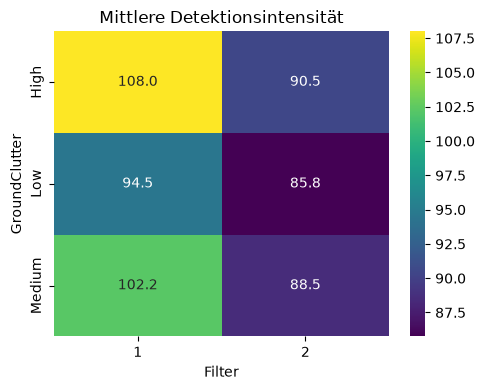

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

sns.heatmap(
    means,
    annot=True,
    fmt=".1f",
    cmap="viridis"
)

plt.title(
    "Mittlere Detektionsintensität"
)

plt.tight_layout()
plt.show()

# Faktorielle ANOVA mit Blockung

Modell:

$
y_{ijk}
=
\mu
+
\tau_i
+
\beta_j
+
(\tau\beta)_{ij}
+
\delta_k
+
\epsilon_{ijk}
$

mit

- Ground Clutter
- Filter Type
- Wechselwirkung
- Operator (Block)

In [8]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

model = ols(
    "Intensity ~ C(GroundClutter)*C(Filter) + C(Operator)",
    data=df
).fit()



anova_table = anova_lm(
    model,
    typ=2
)

anova_table["MS"] = (
    anova_table["sum_sq"]
    /
    anova_table["df"]
)

anova_table.round(3)

,sum_sq,df,F,PR(>F),MS
C(GroundClutter),335.583,2.0,15.132,0.000,167.792
C(Filter),1066.667,1.0,96.192,0.000,1066.667
C(Operator),402.167,3.0,12.089,0.000,134.056
C(GroundClutter):C(Filter),77.083,2.0,3.476,0.058,38.542
Residual,166.333,15.0,NaN,NaN,11.089


In [9]:
anova_table["Percent"] = (
    100
    *
    anova_table["sum_sq"]
    /
    anova_table["sum_sq"].sum()
)

anova_table.round(2)

,sum_sq,df,F,PR(>F),MS,Percent
C(GroundClutter),335.58,2.0,15.13,0.00,167.79,16.39
C(Filter),1066.67,1.0,96.19,0.00,1066.67,52.09
C(Operator),402.17,3.0,12.09,0.00,134.06,19.64
C(GroundClutter):C(Filter),77.08,2.0,3.48,0.06,38.54,3.76
Residual,166.33,15.0,NaN,NaN,11.09,8.12


# Haupteffekte
## Ground Clutter

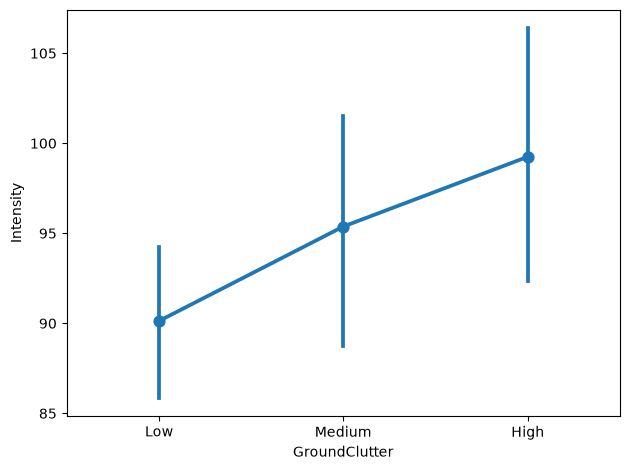

In [10]:
sns.pointplot(
    data=df,
    x="GroundClutter",
    y="Intensity",
    errorbar=("ci",95)
)

plt.tight_layout()
plt.show()

## Filter Type

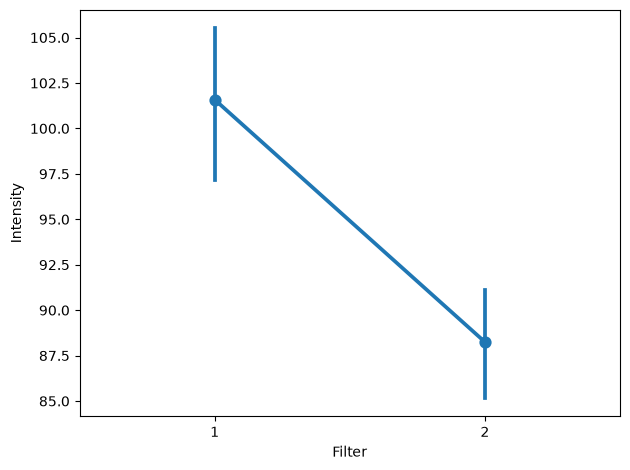

In [11]:
sns.pointplot(
    data=df,
    x="Filter",
    y="Intensity",
    errorbar=("ci",95)
)

plt.tight_layout()
plt.show()

## Interaction Plot

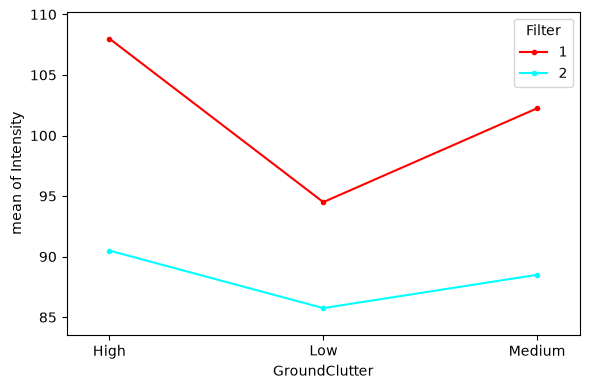

In [12]:
from statsmodels.graphics.factorplots import interaction_plot

fig, ax = plt.subplots(
    figsize=(6,4)
)

interaction_plot(
    df["GroundClutter"],
    df["Filter"],
    df["Intensity"],
    ax=ax
)

plt.tight_layout()
plt.show()

# Residuenanalyse
## QQ-Plot

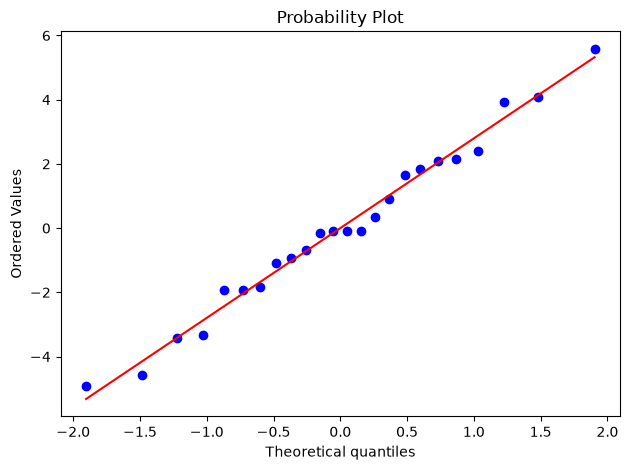

In [13]:
from scipy import stats

stats.probplot(
    model.resid,
    dist="norm",
    plot=plt
)

plt.tight_layout()
plt.show()

## Residuen gegen Fits

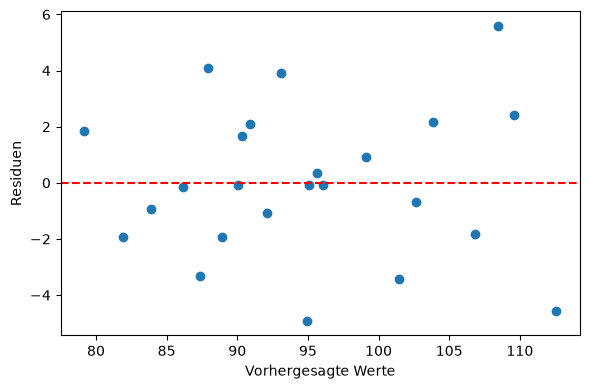

In [14]:
plt.figure(figsize=(6,4))

plt.scatter(
    model.fittedvalues,
    model.resid
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Vorhergesagte Werte")
plt.ylabel("Residuen")

plt.tight_layout()
plt.show()

# Random Effect für Operator

Die Bedienpersonen wurden zufällig ausgewählt.

Deshalb können die Operatoren als Zufallseffekt modelliert werden.

In [15]:
from statsmodels.regression.mixed_linear_model import MixedLM

mixed_model = MixedLM.from_formula(
    "Intensity ~ C(GroundClutter)*C(Filter)",
    groups="Operator",
    data=df
)

mixed_result = mixed_model.fit()

print(
    mixed_result.summary()
)

                         Mixed Linear Model Regression Results
Model:                        MixedLM           Dependent Variable:           Intensity
No. Observations:             24                Method:                       REML     
No. Groups:                   4                 Scale:                        11.0889  
Min. group size:              6                 Log-Likelihood:               -55.0917 
Max. group size:              6                 Converged:                    Yes      
Mean group size:              6.0                                                      
---------------------------------------------------------------------------------------
                                           Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------------------
Intercept                                 108.000    2.810 38.435 0.000 102.493 113.507
C(GroundClutter)[T.Low]                   -13.500    2.35

## Varianzkomponenten

In [16]:
sigma2_operator = (
    mixed_result.cov_re.iloc[0,0]
)

sigma2_error = (
    mixed_result.scale
)

total = (
    sigma2_operator
    +
    sigma2_error
)

print(
    f"Operator variance: "
    f"{sigma2_operator:.2f}"
)

print(
    f"Error variance: "
    f"{sigma2_error:.2f}"
)

print(
    f"Percent due to operator: "
    f"{100*sigma2_operator/total:.1f}%"
)

Operator variance: 20.49
Error variance: 11.09
Percent due to operator: 64.9%


# Fazit

- Ground Clutter beeinflusst die Zielerkennung signifikant.
- Filter Type beeinflusst die Zielerkennung signifikant.
- Die Wechselwirkung ist schwach bis moderat.
- Die Operatoren verursachen einen großen Teil der Variabilität.

Die Blockung war daher sinnvoll und reduziert die Fehlervarianz deutlich.